In [6]:
import numpy as np
import agama
import matplotlib.pyplot as plt
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

agama.setUnits(length=1, velocity=1, mass=1)  # kpc, km/s, Solar mass


In [7]:
pot_mw = agama.Potential(
    dict(type='Dehnen', mass=1.0e10, scaleRadius=1.0, gamma=1),       # Bulge
    dict(type='MiyamotoNagai', mass=5.0e10, scaleRadius=3.0, scaleHeight=0.3),  # Disk
    dict(type='NFW', mass=2e12, scaleRadius=22.0))                     # Dark matter halo

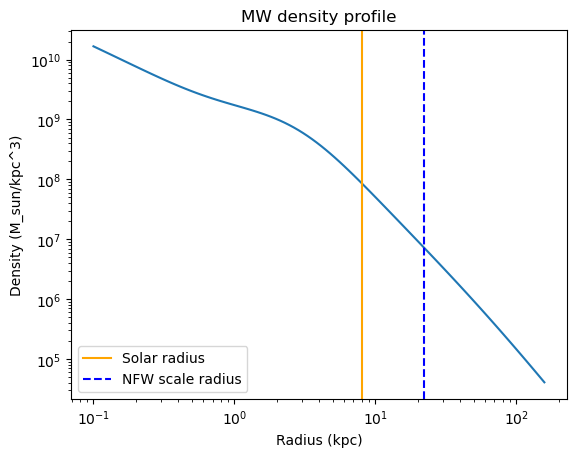

In [8]:
# Non-essential: MW density profile
r_array = np.logspace(-1, 2.2, 100)
pts = np.column_stack((r_array, np.zeros_like(r_array), np.zeros_like(r_array)))
rho_mw = pot_mw.density(pts)

plt.figure()
plt.loglog(r_array, rho_mw)
plt.axvline(8.0, color='orange', label='Solar radius')
plt.axvline(22.0, color='b', linestyle='--', label='NFW scale radius')
plt.xlabel('Radius (kpc)')
plt.ylabel('Density (M_sun/kpc^3)')
plt.title('MW density profile')
plt.legend()
plt.show()

In [9]:
mc_mass0 = 1e-9   # Solar masses
mc_rvir  = 1e-10  # virial radius [kpc]
mc_rs    = 1e-12  # scale radius [kpc]
Nbody    = 1000

In [10]:
pot_mc = agama.Potential(
    type='Multipole',
    density='Spheroid',
    gamma=1, beta=3,
    scaleRadius=mc_rs,
    outerCutoffRadius=mc_rvir,
    mass=mc_mass0,
    rmin=1e-13,
    rmax=10,
    gridSizeR=60,
    lmax=0,
)

In [11]:
df_mc   = agama.DistributionFunction(type='quasispherical', potential=pot_mc)


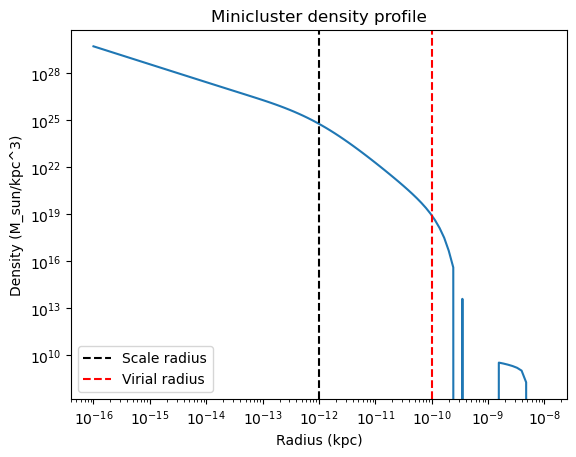

In [12]:
# Non-essential: minicluster density profile
r_mc = np.logspace(-16, -8, 100)
pts_mc = np.column_stack((r_mc, np.zeros_like(r_mc), np.zeros_like(r_mc)))
rho_mc = agama.GalaxyModel(pot_mc, df_mc).moments(pts_mc, dens=True, vel=False, vel2=False)

plt.figure()
plt.loglog(r_mc, rho_mc)
plt.axvline(mc_rs,   color='k',  linestyle='--', label='Scale radius')
plt.axvline(mc_rvir, color='r',  linestyle='--', label='Virial radius')
plt.xlabel('Radius (kpc)')
plt.ylabel('Density (M_sun/kpc^3)')
plt.title('Minicluster density profile')
plt.legend()
plt.show()

In [13]:

mcp_xv, mcp_mass = agama.GalaxyModel(pot_mc, df_mc).sample(Nbody)


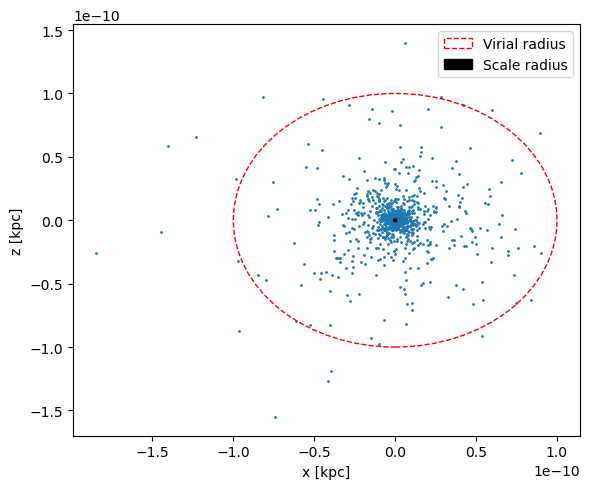

In [14]:
# Non-essential: initial particle distribution
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(mcp_xv[:, 0], mcp_xv[:, 2], s=1)
ax.add_patch(plt.Circle((0, 0), mc_rvir, color='r', fill=False, linestyle='--', label='Virial radius'))
ax.add_patch(plt.Circle((0, 0), mc_rs,   color='k', fill=True,  label='Scale radius'))
ax.set_xlabel('x [kpc]')
ax.set_ylabel('z [kpc]')
ax.legend()
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Number of particles')

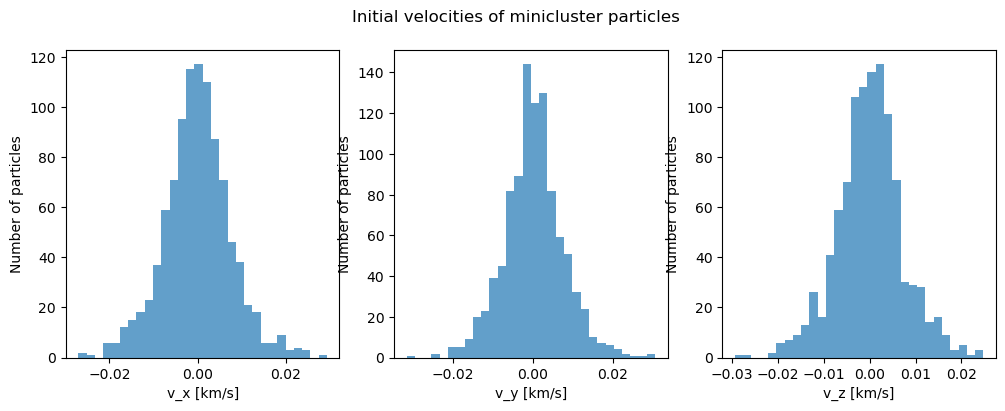

In [16]:
fig,ax=plt.subplots(1,3, figsize=(12,4))
fig.suptitle('Initial velocities of minicluster particles')

ax[0].hist(mcp_xv[:,3], bins=30, alpha=0.7, label='v_x')
ax[0].set_xlabel('v_x [km/s]')
ax[0].set_ylabel('Number of particles')
ax[1].hist(mcp_xv[:,4], bins=30, alpha=0.7, label='v_y')
ax[1].set_xlabel('v_y [km/s]')
ax[1].set_ylabel('Number of particles')
ax[2].hist(mcp_xv[:,5], bins=30, alpha=0.7, label='v_z')
ax[2].set_xlabel('v_z [km/s]')
ax[2].set_ylabel('Number of particles')


In [17]:
orbit_time      = pot_mw.Tcirc(mc_center)
simulation_time = 2 * orbit_time
tupd            = 1e-3  # update interval [Gyr]: CoM step + N-body step
print(f'Circular orbit period: {orbit_time:.4f} Gyr')
print(f'Simulation time: {simulation_time:.4f} Gyr  ({int(round(simulation_time/tupd))} steps)')

# Save initial state for before/after comparison
mcp_xv_init    = mcp_xv.copy()
mc_center_init = mc_center.copy()

times_u = [0.0]
mc_mass = [mc_mass0]
mc_traj = [mc_center.copy()]
bound   = np.ones(len(mcp_xv), dtype=bool)  # all particles start bound
time_i  = 0.0

NameError: name 'mc_center' is not defined

In [18]:
from tqdm.notebook import tqdm  # re-import to avoid namespace conflicts

n_steps = int(round(simulation_time / tupd))

with tqdm(total=n_steps, desc='Simulation') as pbar:
    while time_i < simulation_time:

        # --- Integrate CoM in MW potential (no dynamical friction) ---
        mc_time_center, mc_orbit_center = agama.orbit(
            ic=mc_center, potential=pot_mw, time=tupd,
            timestart=time_i, trajsize=100, accuracy=1e-10)
        times_u.append(mc_time_center[-1])
        mc_traj.extend(mc_orbit_center[1:])
        mc_center = mc_orbit_center[-1]

        # --- Advance N-body particles in combined MW + moving cluster potential ---
        pot_total = agama.Potential(
            pot_mw,
            agama.Potential(potential=pot_mc,
                            center=np.column_stack((mc_time_center, mc_orbit_center))))
        mcp_xv = np.vstack(
            agama.orbit(ic=mcp_xv, potential=pot_total,
                        time=tupd, timestart=time_i, trajsize=1, accuracy=1e-10)[:, 1])

        # --- Relative coordinates in cluster rest frame ---
        rel_pos = mcp_xv[:, :3] - mc_center[:3]
        rel_vel = mcp_xv[:, 3:6] - mc_center[3:6]

        # --- Jacobi (tidal) radius: r_t = r_orb * (M_mc / 3*M_enc)^(1/3) ---
        r_orb   = np.linalg.norm(mc_center[:3])
        M_enc   = pot_mw.enclosedMass(r_orb)
        r_tidal = r_orb * (mc_mass[-1] / (3 * M_enc))**(1/3) if mc_mass[-1] > 0 else mc_rvir

        # --- Rebuild cluster potential from bound particles only ---
        n_bound = np.sum(bound)
        if n_bound > 10:
            pot_mc = agama.Potential(
                type='multipole',
                particles=(rel_pos[bound], mcp_mass[bound]),
                symmetry='n', lmax=4)  # no imposed symmetry: tidal stripping breaks it


        # --- Update bound mask ---
        bound_energy = pot_mc.potential(rel_pos) + 0.5 * np.sum(rel_vel**2, axis=1) < 0
        bound_dist   = np.sum(rel_pos**2, axis=1) < r_tidal**2
        bound        = bound_energy & bound_dist

        mc_mass.append(np.sum(mcp_mass[bound]))
        time_i += tupd

        # --- Checkpoint every 50 steps ---
        if int(round(time_i / tupd)) % 50 == 0:
            np.savez('checkpoint.npz',
                     mcp_xv=mcp_xv, mcp_mass=mcp_mass,
                     mc_mass=mc_mass, mc_traj=mc_traj,
                     times_u=times_u, time_i=time_i, bound=bound)

        pbar.update(1)

NameError: name 'simulation_time' is not defined

In [ ]:
%matplotlib inline

# --- Initial and final minicluster particle distribution (cluster rest frame) ---
rel_pos_init = mcp_xv_init[:, :3] - mc_center_init[:3]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# --- Initial ---
ax = axes[0]
ax.scatter(rel_pos_init[:, 0], rel_pos_init[:, 2], s=1, color='steelblue', alpha=0.6)
ax.add_patch(plt.Circle((0, 0), mc_rvir, color='r', fill=False,
                         linestyle='--', linewidth=1.2, label=f'Virial radius ({mc_rvir:.0e} kpc)'))
ax.add_patch(plt.Circle((0, 0), mc_rs,   color='k', fill=False,
                         linestyle=':',  linewidth=1.2, label=f'Scale radius ({mc_rs:.0e} kpc)'))
ax.set_xlabel('x [kpc]')
ax.set_ylabel('z [kpc]')
ax.set_title(f'Initial  (t = 0 Gyr,  N = {Nbody})')
ax.set_aspect('equal')
ax.legend(fontsize=8)

# --- Final ---
ax = axes[1]
ax.scatter(rel_pos[bound,  0], rel_pos[bound,  2], s=2,   color='limegreen',
           label=f'Bound ({bound.sum()})')
ax.scatter(rel_pos[~bound, 0], rel_pos[~bound, 2], s=0.5, color='crimson', alpha=0.3,
           label=f'Unbound ({(~bound).sum()})')
ax.add_patch(plt.Circle((0, 0), r_tidal, color='orange', fill=False,
                         linestyle='--', linewidth=1.2, label=f'Tidal radius ({r_tidal:.2e} kpc)'))
ax.set_xlabel('x [kpc]')
ax.set_ylabel('z [kpc]')
ax.set_title(f'Final  (t = {simulation_time:.3f} Gyr,  bound fraction = {bound.mean():.3f})')
ax.set_aspect('equal')
ax.legend(fontsize=8)

plt.suptitle('Minicluster particle distribution (cluster rest frame)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
%matplotlib inline

# --- Orbit of the minicluster around the MW ---
traj = np.vstack(mc_traj)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(traj[:, 0], traj[:, 2], color='steelblue', linewidth=1.5, label='MC orbit')
ax.scatter(*traj[0, [0, 2]],  marker='o', s=120, color='limegreen', zorder=5, label='Start')
ax.scatter(*traj[-1, [0, 2]], marker='s', s=120, color='crimson',   zorder=5, label='End')
ax.scatter([0], [0], marker='*', s=400, color='gold', edgecolors='orange', zorder=5, label='MW centre')
ax.set_xlabel('x [kpc]')
ax.set_ylabel('z [kpc]')
ax.set_title('Minicluster orbit around the Milky Way')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times_u, np.array(mc_mass) / mc_mass0, color='steelblue')
ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax.set_xlabel('Time [Gyr]')
ax.set_ylabel('Bound mass fraction $M/M_0$')
ax.set_title('Minicluster mass loss')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print(f"Bound fraction (energy only): {bound_energy.mean():.4f}")
print(f"Bound fraction (dist only):   {bound_dist.mean():.4f}")
print(f"Bound fraction (both):        {bound.mean():.4f}")
print(f"Bound count: {bound.sum()} / {len(bound)}")

In [ ]:
plt.scatter(rel_pos[:,  0], rel_pos[:,  2], s=2)


In [ ]:
plt.scatter(rel_pos[:,  0], rel_pos[:,  1], s=2)


In [ ]:
%matplotlib inline

# --- MW potential map + tidal stream side by side ---
# Build 2D MW density grid in x-z plane
lim   = 25.0
ngrid = 300
xg    = np.linspace(-lim, lim, ngrid)
zg    = np.linspace(-lim, lim, ngrid)
XX, ZZ = np.meshgrid(xg, zg)
pts_grid = np.column_stack((XX.ravel(), np.zeros(ngrid**2), ZZ.ravel()))
rho_grid = pot_mw.density(pts_grid).reshape(ngrid, ngrid)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Left: MW density map with orbit and tidal stream ---
ax = axes[0]
im = ax.pcolormesh(xg, zg, np.log10(rho_grid + 1e-30),
                   cmap='magma', shading='auto')
plt.colorbar(im, ax=ax, label=r'$\log_{10}(\rho\ [M_\odot\,\mathrm{kpc}^{-3}])$')

traj = np.vstack(mc_traj)
ax.plot(traj[:, 0], traj[:, 2], color='cyan', linewidth=0.8, alpha=0.7, label='MC orbit')
ax.scatter(mcp_xv[~bound, 0], mcp_xv[~bound, 2],
           s=0.3, color='yellow', alpha=0.5, label=f'Tidal stream ({(~bound).sum()})')
ax.scatter(mcp_xv[bound,  0], mcp_xv[bound,  2],
           s=1.5, color='limegreen', label=f'Bound ({bound.sum()})')
ax.scatter(*traj[0,  [0, 2]], marker='o', s=80,  color='limegreen', zorder=6, label='Start')
ax.scatter(*traj[-1, [0, 2]], marker='s', s=80,  color='crimson',   zorder=6, label='End')
ax.scatter(0, 0, marker='*', s=300, color='gold', edgecolors='orange', zorder=6, label='MW centre')

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel('x [kpc]')
ax.set_ylabel('z [kpc]')
ax.set_title('MW density + minicluster orbit & tidal stream')
ax.set_aspect('equal')
ax.legend(fontsize=7, loc='upper right')

# --- Right: cluster rest frame, zoomed out to show full spread of stripped particles ---
ax = axes[1]
# Set zoom to encompass all particles (bound + unbound)
spread = np.percentile(np.abs(rel_pos[:, [0, 2]]), 99) * 1.2
ax.scatter(rel_pos[bound,  0], rel_pos[bound,  2], s=2,   color='limegreen',
           label=f'Bound ({bound.sum()})')
ax.scatter(rel_pos[~bound, 0], rel_pos[~bound, 2], s=0.5, color='crimson', alpha=0.4,
           label=f'Unbound ({(~bound).sum()})')
ax.add_patch(plt.Circle((0, 0), r_tidal, color='orange', fill=False,
                         linestyle='--', linewidth=1.2, label=f'Tidal radius ({r_tidal:.2e} kpc)'))
ax.add_patch(plt.Circle((0, 0), mc_rvir, color='white', fill=False,
                         linestyle=':', linewidth=1.0, label=f'Virial radius ({mc_rvir:.0e} kpc)'))
ax.set_xlim(-spread, spread)
ax.set_ylim(-spread, spread)
ax.set_xlabel('x [kpc]  (cluster frame)')
ax.set_ylabel('z [kpc]  (cluster frame)')
ax.set_title(f'Cluster rest frame  (t = {simulation_time:.3f} Gyr,  bound = {bound.mean():.3f})')
ax.set_aspect('equal')
ax.legend(fontsize=8)

plt.suptitle('Minicluster in the Milky Way', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# Covariance matrix of particle positions (use bound only, or all)
cov = np.cov(rel_pos.T)          # shape (3, 3)
eigenvalues, eigenvectors = np.linalg.eigh(cov)

# Eigenvalues sorted ascending by default; reverse for descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]     # columns are eigenvectors

principal_axis = eigenvectors[:, 0]     # direction of max elongation
print(f'Eigenvalues:     {eigenvalues}')
print(f'Principal axis:  {principal_axis}')
print(f'sigma along axes: {np.sqrt(eigenvalues)}')


In [ ]:
# eigenvectors columns: [principal, secondary, tertiary]
# After rotation, col 0 = elongation axis → becomes new x
rel_pos_rot = rel_pos @ eigenvectors   # shape (N, 3)

# Now rel_pos_rot[:, 0] is along the principal axis
# rel_pos_rot[:, 1] is the second axis
# rel_pos_rot[:, 2] is the most compressed axis
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(rel_pos_rot[:, 0], rel_pos_rot[:, 1], s=1, alpha=0.5)
ax.set_xlabel('Principal axis (elongation)')
ax.set_ylabel('Secondary axis')
ax.set_aspect('equal')
ax.set_title('Particles aligned along principal axis')
plt.show()


In [ ]:
plt.scatter(rel_pos_rot[:, 0], rel_pos_rot[:,1], s=1, alpha=0.5)

In [ ]:
r = np.linalg.norm(rel_pos, axis=1)

bins = np.logspace(np.log10(r.min()), np.log10(r.max()), 50)
counts, edges = np.histogram(r, bins=bins)
r_mid = 0.5 * (edges[:-1] + edges[1:])
vol   = (4/3) * np.pi * (edges[1:]**3 - edges[:-1]**3)
rho   = (counts * mcp_mass[bound].mean()) / vol   # M_sun / kpc^3

plt.figure()
plt.loglog(r_mid, rho)
plt.xlabel('r [kpc]')
plt.ylabel(r'$\rho\ [M_\odot\,\mathrm{kpc}^{-3}]$')
plt.title('Bound halo density profile')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import gaussian_kde

xy = np.vstack([rel_pos_rot[:, 0], rel_pos_rot[:, 2]])
density = gaussian_kde(xy)(xy)

# Sort by density so denser points plot on top
order = np.argsort(density)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(rel_pos_rot[:, 0][order], rel_pos_rot[:, 2][order],
                c=density[order], s=1, cmap='inferno')
plt.colorbar(sc, ax=ax, label='Density')
ax.set_xlabel('x [kpc]  (cluster frame)')
ax.set_ylabel('z [kpc]  (cluster frame)')
#ax.set_xlim(-0.0004, 0.0004)
#ax.set_ylim(-0.0012, 0.0012)
plt.tight_layout()
plt.show()


In [ ]:
agama.setUnits(length=1e-6, velocity=1, mass=1e-6)
mc_mass0 = 1   # Solar masses
mc_rvir  = 1e-3  # virial radius [kpc]
mc_rs    = 1e-4  # scale radius [kpc]
Nbody    = 1000

pot_mc = agama.Potential(
    type='spheroid', gamma=1, beta=3,
    scaleradius=mc_rs, outercutoffradius=mc_rvir, mass=mc_mass0)


In [ ]:
pot_mc.totalMass()

In [ ]:
r=np.logspace(-10, -2, 1000)
pts = np.column_stack([r, np.zeros_like(r), np.zeros_like(r)])
pot=pot_mc.potential(pts)
plt.semilogx(r, pot)


In [ ]:
def plot_nfw(M, r_vir, r_s):
    pot = agama.Potential(type='NFW', mass=M, scaleRadius=r_s)
    
    r = np.logspace(np.log10(r_s/100), np.log10(r_vir*10), 200)
    pts = np.column_stack([r, np.zeros_like(r), np.zeros_like(r)])
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    
    ax[0].loglog(r, pot.density(pts))
    ax[0].axvline(r_s,   color='k', linestyle='--', label='r_scale')
    ax[0].axvline(r_vir, color='r', linestyle='--', label='r_vir')
    ax[0].set_xlabel('r [kpc]')
    ax[0].set_ylabel('density [M☉/kpc³]')
    ax[0].legend()

    ax[1].loglog(r, -pot.potential(pts))
    ax[1].axvline(r_s,   color='k', linestyle='--', label='r_scale')
    ax[1].axvline(r_vir, color='r', linestyle='--', label='r_vir')
    ax[1].set_xlabel('r [kpc]')
    ax[1].set_ylabel('potential [(km/s)²]')
    ax[1].legend()
    
    plt.tight_layout()
    plt.show()
    return 

plot_nfw(M=1e-9, r_vir=1e-8, r_s=1e-9)


In [ ]:
df_mc   = agama.DistributionFunction(type='quasispherical', potential=pot_mc)


In [ ]:
pot_mc = agama.Potential(
    type='spheroid', gamma=1, beta=3,
    scaleradius=mc_rs, outercutoffradius=mc_rvir, mass=mc_mass0)


In [ ]:
pip show agama

In [ ]:
help(agama.Potential)